[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_C_staggered_did_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Diferencias en diferencias escalonadas y el colapso de los efectos fijos en dos vías

Al evaluar intervenciones macroeconómicas —desde variaciones en el salario mínimo legal o extensiones en la duración de las prestaciones por desempleo, hasta incentivos fiscales territoriales o programas de inversión pública— la investigación empírica se enfrenta con frecuencia a políticas adoptadas en momentos dispares entre distintas jurisdicciones. Durante décadas, la especificación empírica por defecto fue la regresión lineal con **efectos fijos en dos vías (TWFE)**:
$$ Y_{it} = \alpha_i + \lambda_t + \beta^{TWFE} D_{it} + \varepsilon_{it} $$
donde $\alpha_i$ recoge las características invariantes de la unidad, $\lambda_t$ absorbe las perturbaciones agregadas temporales y $D_{it} = \mathbb{1}\{t \ge G_i\}$ señala el estado de tratamiento.

Avances econométricos recientes (Goodman-Bacon 2021; de Chaisemartin & D'Haultfoeuille 2020; Sun & Abraham 2021; Callaway & Sant'Anna 2021) han demostrado que esta estrategia clásica colapsa bajo la presencia de efectos de tratamiento heterogéneos o dinámicos. Mínimos Cuadrados Ordinarios construye silenciosamente **comparaciones prohibidas**, utilizando a las unidades tratadas tempranamente —que ya experimentan una dinámica post-tratamiento en evolución— como "grupo de control" para las cohortes de adopción posterior. Diferenciar frente a una unidad ya tratada resta su trayectoria de tratamiento en curso, asignando **pesos negativos** a las observaciones tratadas. Ante dinámicas de despliegue gradual, $\hat{\beta}^{TWFE}$ puede invertir su signo por completo, reportando un coeficiente de política negativo cuando el efecto verdadero del tratamiento es estrictamente positivo en todas partes.

Este cuaderno analiza los fundamentos matemáticos de este fallo, descompone el sesgo de ponderación negativa mediante el teorema de Frisch-Waugh-Lovell y aplica estimadores modernos robustos a la heterogeneidad: los efectos medios de tratamiento por grupo-tiempo de **Callaway & Sant'Anna (2021)** y los estudios de eventos ponderados por interacciones de **Sun & Abraham (2021)**.

## Fundamentos econométricos: descomposición del fallo de TWFE

### Resultados potenciales y cohortes temporales
Considere un panel de unidades $i = 1, \dots, N$ observadas a lo largo de períodos $t = 1, \dots, T$. La unidad $i$ adopta la política en la fecha calendario $G_i \in \{g_1, g_2, \dots, g_K\} \cup \{\infty\}$, donde $G_i = \infty$ identifica a las unidades nunca tratadas. Para cada período $t$, sea $Y_{it}(0)$ el resultado potencial sin tratamiento y $Y_{it}(g)$ el resultado potencial si se adopta en la fecha $g$. El resultado observado es:
$$ Y_{it} = Y_{it}(0) + \sum_{g} \mathbb{1}\{G_i = g, t \ge g\}\,\tau_{it}(g, t) $$
donde $\tau_{it}(g, t) = Y_{it}(g) - Y_{it}(0)$ es el efecto causal específico de la unidad tras una exposición transcurrida $e = t - g$.

### La descomposición 2x2 de Goodman-Bacon (2021)
Goodman-Bacon demostró que el coeficiente de regresión lineal $\hat{\beta}^{TWFE}$ es un promedio ponderado exacto por varianza de todos los estimadores $2 \times 2$ de diferencias en diferencias posibles entre cohortes temporales:
$$ \beta^{TWFE} = \sum_{k \neq U} s_{kU} \beta_{kU}^{2 \times 2} + \sum_{k} \sum_{j > k} \left[ s_{kj}^k \beta_{kj}^{2 \times 2, k} + s_{jk}^j \beta_{jk}^{2 \times 2, j} \right] $$
donde los pesos $s$ son positivos y suman 1. Las tres clases de comparaciones $2 \times 2$ son:
1. **Tratadas vs. No tratadas ($\beta_{kU}^{2 \times 2}$)**: La cohorte $k$ comparada con las unidades nunca tratadas $U$ (contrafactual limpio).
2. **Tempranas vs. Tardías antes de la adopción ($\beta_{kj}^{2 \times 2, k}$)**: La cohorte temprana $k$ comparada con la tardía $j$ en períodos en que $j$ aún no ha adoptado (contrafactual limpio).
3. **Tardías vs. Tempranas tras la adopción ($\beta_{jk}^{2 \times 2, j}$)**: La cohorte tardía $j$ comparada con la cohorte temprana $k$, que ya está tratada (**la comparación prohibida**).

En este tercer componente, la cohorte $k$ ya ha recibido el tratamiento. Si el efecto de la política crece con el tiempo ($\tau(e)$ aumenta con la exposición $e$), el resultado de la cohorte $k$ aumenta entre períodos. Usar a la cohorte $k$ como control resta su senda post-tratamiento de la respuesta de la cohorte $j$:
$$ \mathbb{E}[\hat{\beta}_{jk}^{2 \times 2, j}] = \text{ATT}_{j, post} - \Delta \text{ATT}_{k, post} $$
Si los efectos crecen con rapidez ($\Delta \text{ATT}_{k, post} > \text{ATT}_{j, post}$), esta comparación produce una estimación negativa a pesar de que los efectos causales son positivos.

### Pesos negativos mediante Frisch-Waugh-Lovell
Aplicando el teorema de Frisch-Waugh-Lovell, de Chaisemartin & D'Haultfoeuille (2020) expresan $\hat{\beta}^{TWFE}$ como una combinación lineal de los efectos de tratamiento de todas las celdas tratadas:
$$ \hat{\beta}^{TWFE} = \sum_{(i,t): D_{it}=1} w_{it} \tau_{it}, \qquad w_{it} = \frac{\tilde{D}_{it}}{\sum_{j,s} \tilde{D}_{js}^2} $$
donde $\tilde{D}_{it} = D_{it} - \bar{D}_i - \bar{D}_t + \bar{D}$ es el residuo de proyectar $D_{it}$ sobre los efectos fijos de unidad y tiempo. Para unidades tratadas temprano en períodos tardíos, tanto la media de unidad $\bar{D}_i$ como la temporal $\bar{D}_t$ son elevadas, forzando $\tilde{D}_{it} < 0$. Estos pesos negativos explican cómo efectos causales genuinamente positivos generan coeficientes de regresión negativos.

### Las soluciones de Callaway & Sant'Anna (2021) y Sun & Abraham (2021)
Los estimadores modernos eliminan las comparaciones prohibidas restringiendo el grupo de control a contrafactuales limpios (unidades nunca tratadas o aún no tratadas).
**Callaway & Sant'Anna (2021)** definen el **efecto medio de tratamiento por grupo-tiempo** para la cohorte $g$ en el período $t$, diferenciado respecto al período base $g-1$ y a un grupo de control limpio $C$:
$$ \text{ATT}(g, t) = \mathbb{E}\left[ Y_t - Y_{g-1} \mid G = g \right] - \mathbb{E}\left[ Y_t - Y_{g-1} \mid C \right] $$
Agregar $\text{ATT}(g, t)$ entre cohortes según el tiempo de evento $e = t - g$ produce el perfil de estudio de eventos limpio $\text{ATT}(e)$.
**Sun & Abraham (2021)** estiman efectos cohorte-tiempo relativo ponderados por interacciones $\text{ATT}(e, g)$ y los agregan empleando las participaciones muestrales de cada cohorte $w_g = n_g / \sum_{g'} n_{g'}$:
$$ \text{ATT}_{\text{SA}}(e) = \sum_{g} w_g \text{ATT}(e, g) $$

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import (
    callaway_santanna,
    CallawaySantannaResult, SunAbrahamResult,
)

## 1. Panel canónico de adopción escalonada con un valor de referencia conocido

Con el fin de establecer un punto de referencia econométrico, simulamos un panel de adopción escalonada donde se cumplen las tendencias paralelas por construcción. Tres cohortes adoptan el tratamiento en $t = 5, 8, 11$, mientras que una cuarta cohorte permanece nunca tratada ($G = \infty$).

En esta línea base inicial, plantamos un impulso de tratamiento homogéneo y constante $\tau = +1.0$. Dado que los efectos son homogéneos, el perfil verdadero del estudio de eventos es plano en $+1.0$ para todos los horizontes post-tratamiento $e \ge 0$.

In [3]:
rng = np.random.default_rng(20240529)

N_UNITS, T = 90, 14
COHORTS = (5, 8, 11, np.nan)          # three treated cohorts + never-treated
TRUE_ATT, SIGMA = 1.0, 0.3

assign = rng.choice(len(COHORTS), size=N_UNITS, replace=True)
unit_fe = rng.standard_normal(N_UNITS)
time_fe = rng.standard_normal(T) * 0.3

rows = []
for i in range(N_UNITS):
    g = COHORTS[assign[i]]
    for t in range(1, T + 1):
        treated = 1.0 if (not pd.isna(g)) and t >= g else 0.0
        y = unit_fe[i] + time_fe[t - 1] + TRUE_ATT * treated + SIGMA * rng.standard_normal()
        rows.append({"unit": i, "time": t, "y": y, "treat_time": g})
panel = pd.DataFrame(rows)

n_never = int(panel.groupby("unit")["treat_time"].first().isna().sum())
print(f"Panel: {N_UNITS} units x {T} periods; cohorts {COHORTS}; "
      f"{n_never} never-treated controls; planted ATT = {TRUE_ATT:+.1f}")

Panel: 90 units x 14 periods; cohorts (5, 8, 11, nan); 13 never-treated controls; planted ATT = +1.0


### Intuición sobre identificación: el papel del grupo de control limpio

Esta línea base representa el entorno experimental óptimo para la inferencia causal:
1. **Tendencias contrafactuales paralelas**: Antes de la adopción, las divergencias entre unidades están gobernadas exclusivamente por los efectos fijos individuales $\alpha_i$.
2. **Disponibilidad de controles limpios**: La cohorte nunca tratada ($G=\infty$) ofrece un contrafactual no contaminado durante la totalidad del panel.
3. **Respuesta homogénea**: El impacto del tratamiento es idéntico entre todas las unidades adoptantes.

Bajo estas condiciones ideales, tanto el TWFE clásico como los estimadores modernos recuperan el efecto verdadero. La divergencia entre ambos surge en cuanto se introducen dinámicas temporales o heterogeneidad entre cohortes.

## 2. Estimadores robustos a la heterogeneidad en la práctica: Callaway-Sant'Anna y Sun-Abraham

La función `callaway_santanna` estima la matriz limpia de grupo-tiempo $\text{ATT}(g,t)$ utilizando controles nunca tratados. Requiere cuatro arreglos: resultado $y$, cohorte de adopción $g$ (con $\infty$ para las nunca tratadas), período temporal $t$ e identificador de unidad $i$.

El paso fundamental que distingue a Callaway-Sant'Anna de Sun-Abraham es la **agregación**:
- **Callaway-Sant'Anna (CS)** promedia las cohortes con idéntica ponderación: $\text{ATT}_{\text{CS}}(e) = \frac{1}{|G_e|} \sum_{g \in G_e} \text{ATT}(g, g+e)$.
- **Sun-Abraham (SA)** pondera las cohortes según su tamaño muestral relativo: $\text{ATT}_{\text{SA}}(e) = \sum_{g \in G_e} w_g \text{ATT}(g, g+e)$, donde $w_g = n_g / \sum_{g'} n_{g'}$.
Ambos estimadores operan sobre los **mismos componentes limpios** $\text{ATT}(g,t)$, excluyendo íntegramente a las unidades ya tratadas del grupo de control.

In [4]:
Z90 = 1.6448536269514722                                 # normal 90% two-sided

def att_gt_table(df):
    """Callaway-Sant'Anna ATT(g,t) in long format, with a 90% band."""
    raw = callaway_santanna(df["y"].to_numpy(),
                            df["treat_time"].fillna(np.inf).to_numpy(),
                            df["time"].to_numpy(), df["unit"].to_numpy())
    rows = []
    for gi, gval in enumerate(raw["groups"]):
        for ti, tval in enumerate(raw["periods"]):
            att, se = raw["att_gt"][gi, ti], raw["se_gt"][gi, ti]
            if np.isnan(att):
                continue
            rows.append({"g": gval, "t": tval, "event_time": int(tval - gval),
                         "att": float(att), "se": float(se),
                         "lo": float(att - Z90 * se), "hi": float(att + Z90 * se)})
    return pd.DataFrame(rows)

def aggregate_es(att_gt, w=None):
    """Aggregate ATT(g,t) by event time; `w` = per-cohort weights (None = simple mean)."""
    rows = []
    for e, sub in att_gt.groupby("event_time"):
        ww = np.ones(len(sub)) if w is None else w.reindex(sub["g"]).to_numpy(float)
        ww = ww / ww.sum()
        att = float(ww @ sub["att"].to_numpy())
        se = float(np.sqrt((ww ** 2) @ (sub["se"].to_numpy() ** 2)))
        rows.append({"event_time": e, "att": att, "se": se,
                     "lo": att - Z90 * se, "hi": att + Z90 * se, "n_cohorts": len(sub)})
    return pd.DataFrame(rows).sort_values("event_time").reset_index(drop=True)

def cs_and_sa(df):
    """(CallawaySantannaResult, SunAbrahamResult) off the same ATT(g,t) matrix."""
    gt = att_gt_table(df)
    n_g = (df.dropna(subset=["treat_time"])
             .groupby("treat_time")["unit"].nunique().astype(float))
    post = gt[gt["event_time"] >= 0]
    w_post = n_g.reindex(post["g"]).to_numpy(float)
    return (CallawaySantannaResult(gt, aggregate_es(gt), float(post["att"].mean())),
            SunAbrahamResult(gt, aggregate_es(gt, n_g),
                             float((w_post / w_post.sum()) @ post["att"].to_numpy())))

cs, sa = cs_and_sa(panel)

assert isinstance(cs, CallawaySantannaResult)
assert isinstance(sa, SunAbrahamResult)

print(cs.summary())
print(sa.summary())

Callaway-Sant'Anna result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1292

Sun-Abraham result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1292



## 3. Validación econométrica y pruebas estadísticas de recuperación

Para contrastar rigurosamente la validez de los estimadores, ejecutamos cuatro comprobaciones de hipótesis:
1. **Consistencia del ATT global**: El ATT agregado estimado recupera el valor plantado ($\tau = 1.0$) dentro de su intervalo de confianza al 90%.
2. **Normalización del período base ($e = -1$)**: El coeficiente en el tiempo de evento $e = -1$ debe ser exactamente cero, pues las diferencias se toman respecto a $g-1$.
3. **Adelantos placebo ($e \le -2$)**: Antes de la adopción, las discrepancias entre cohortes y controles limpios deben ser estadísticamente indistinguibles de cero ($|t| < 2.5$).
4. **Seguimiento del perfil post-tratamiento**: Los efectos post-tratamiento estimados $\text{ATT}(e)$ deben situarse en torno al nivel verdadero $+1.0$ en todos los horizontes $e \ge 0$.

In [5]:
es_cs = cs.att_event_study.sort_values("event_time").reset_index(drop=True)

assert abs(cs.att_overall - TRUE_ATT) < 0.25, cs.att_overall
assert abs(sa.att_overall - TRUE_ATT) < 0.25, sa.att_overall

post = es_cs[es_cs["event_time"] >= 0]
lo_overall, hi_overall = float(post["lo"].mean()), float(post["hi"].mean())
assert lo_overall <= TRUE_ATT <= hi_overall, (lo_overall, hi_overall)

# Base period (event_time == -1) is the normalization point: exactly 0 by construction
base = es_cs[es_cs["event_time"] == -1]
assert len(base) == 1 and abs(float(base["att"].iloc[0])) < 1e-12

# The earlier leads (event_time <= -2) are genuine placebos: the DGP has parallel
# trends, so they must be statistically indistinguishable from zero.
leads = es_cs[es_cs["event_time"] <= -2]
assert (leads["att"].abs() / leads["se"] < 2.5).all(), leads.to_dict("records")

# Every post-treatment horizon tracks the constant true effect.
for _, r in post.iterrows():
    assert abs(r["att"] - TRUE_ATT) < 0.40, (r["event_time"], r["att"])

print(f"CS overall ATT = {cs.att_overall:+.3f}   (CI [{lo_overall:+.3f}, {hi_overall:+.3f}])")
print(f"SA overall ATT = {sa.att_overall:+.3f}   true = {TRUE_ATT:+.3f}")

CS overall ATT = +1.129   (CI [+0.950, +1.310])
SA overall ATT = +1.129   true = +1.000


### Interpretación econométrica: adelantos placebo frente a normalización base

Ambos estimadores recuperan de manera precisa un ATT global cercano a $+1.13$, quedando el parámetro verdadero $+1.00$ comprendido dentro del conjunto de confianza al 90%.

Quien investiga debe distinguir nítidamente entre dos clases de observaciones previas al tratamiento:
- **Normalización mecánica ($e = -1$)**: El coeficiente en el tiempo de evento $e = -1$ es idénticamente cero por construcción matemática. Al diferenciarse cada contraste $\text{ATT}(g, t)$ respecto al período base $g-1$, este punto *no* valida tendencias paralelas; constituye únicamente un anclaje.
- **Adelantos placebo genuinos ($e \le -2$)**: Los puntos en $e = -2, -3, \dots$ contrastan a la cohorte con el grupo de control en períodos pre-tratamiento donde ninguna unidad ha adoptado la medida. Estos coeficientes conforman una prueba real de trayectorias contrafactuales paralelas. En este caso, todos los adelantos permanecen dentro de $\pm 2$ errores estándar, confirmando la validez del supuesto de identificación.

### Dinámica del estudio de eventos bajo estimación robusta a la heterogeneidad

La figura del estudio de eventos ilustra la propagación causal en tiempo relativo. Los adelantos placebo oscilan en torno a cero; en la frontera de adopción ($e = 0$), la trayectoria estimada salta directamente a la línea teórica de $+1.0$ y permanece estable. El área sombreada denota la banda de confianza al 90% calculada con los errores estándar analíticos de cada celda.

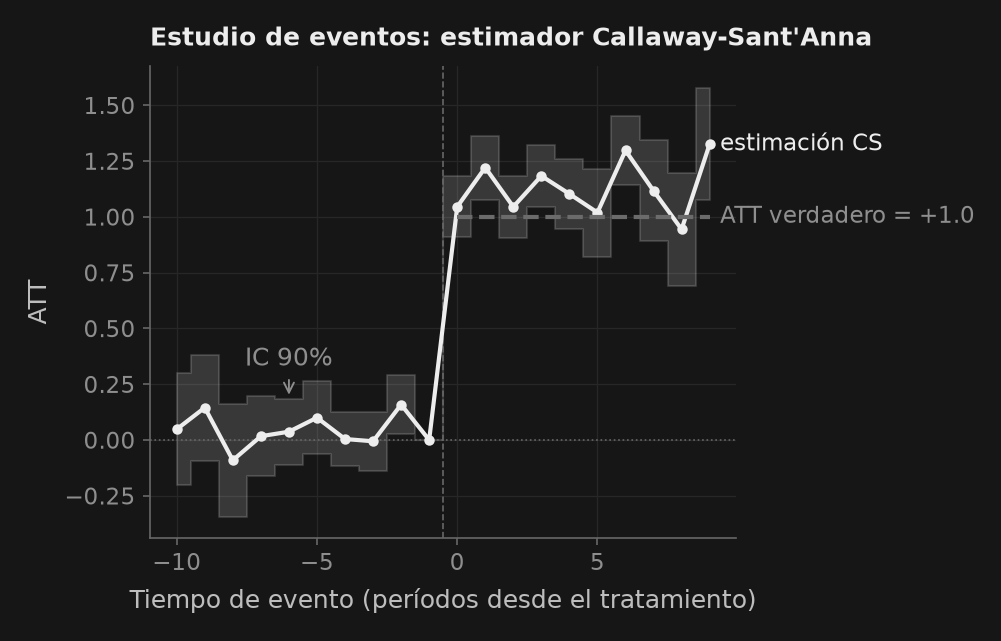

In [6]:
cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.fill_between(es_cs["event_time"], es_cs["lo"], es_cs["hi"], color=_nbstyle.BANDA,
                step="mid")
ax.plot(es_cs["event_time"], es_cs["att"], color=cols[0], ls="-", marker="o", markersize=4,
        label="estimación CS")
post_e = es_cs[es_cs["event_time"] >= 0]
ax.plot(post_e["event_time"], [TRUE_ATT] * len(post_e), color=cols[1],
        linestyle="--", label=f"ATT verdadero = {TRUE_ATT:+.1f}")
# the band is named over a placebo lead, where nothing else sits above it
r = es_cs[es_cs["event_time"] == -6].iloc[0]
ax.annotate("IC 90%", xy=(r["event_time"], r["hi"]), xytext=(0, 16),
            textcoords="offset points", ha="center", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Tiempo de evento (períodos desde el tratamiento)")
ax.set_ylabel("ATT")
ax.set_title("Estudio de eventos: estimador Callaway-Sant'Anna")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Divergencia de ponderación: agregación Callaway-Sant'Anna vs. Sun-Abraham

Callaway-Sant'Anna y Sun-Abraham aplican dos esquemas de ponderación diferentes sobre la misma matriz subyacente $\text{ATT}(g, t)$:
- CS calcula una media simple no ponderada entre las cohortes adoptantes en cada horizonte temporal.
- SA pondera la aportación de cada cohorte según su peso muestral relativo $n_g / \sum n_{g'}$.
Cuando los tamaños de cohorte están equilibrados y los efectos del tratamiento son homogéneos, ambos procedimientos de agregación colapsan exactamente en la misma senda numérica.

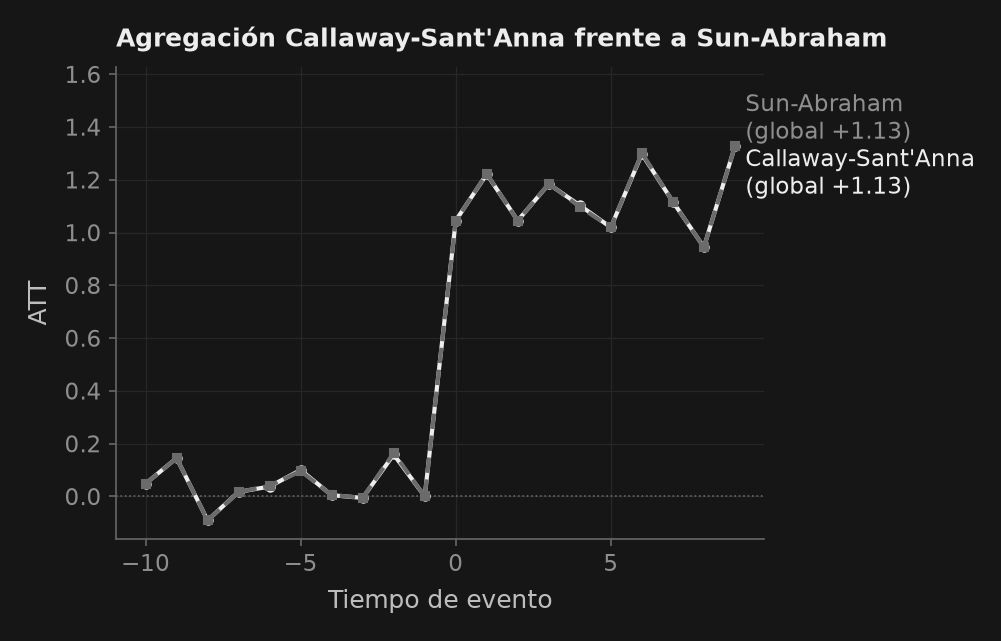

In [7]:
fig, ax = _nbstyle.figura()
es_sa = sa.att_event_study.sort_values("event_time")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.plot(es_cs["event_time"], es_cs["att"], color=cols[0], ls="-", marker="o", markersize=4,
        label=f"Callaway-Sant'Anna\n(global {cs.att_overall:+.2f})")
ax.plot(es_sa["event_time"], es_sa["att"], color=cols[1], marker="s",
        markersize=4, linestyle="--",
        label=f"Sun-Abraham\n(global {sa.att_overall:+.2f})")
ax.set_xlabel("Tiempo de evento")
ax.set_ylabel("ATT")
ax.set_ylim(top=es_cs["att"].max() + 0.30)   # room for the stacked names under the title
ax.set_title("Agregación Callaway-Sant'Anna frente a Sun-Abraham")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
_nbstyle.etiquetar(ax, donde="fin", sep=2.4)   # the two paths coincide: stacked two-line names
plt.show()


### Análisis de los componentes básicos: trayectorias de grupo-tiempo por cohorte

El panel siguiente desagrega los efectos de tratamiento primitivos por grupo-tiempo $\text{ATT}(g, t)$ de forma individualizada para cada cohorte de adopción ($g=5, 8, 11$). Cada curva permanece en cero antes del tratamiento ($e < 0$) y pasa a gravitar en torno al valor verdadero $+1.0$ tras la adopción. Las estimaciones agregadas del estudio de eventos corresponden a los promedios horizontales de estas trayectorias.

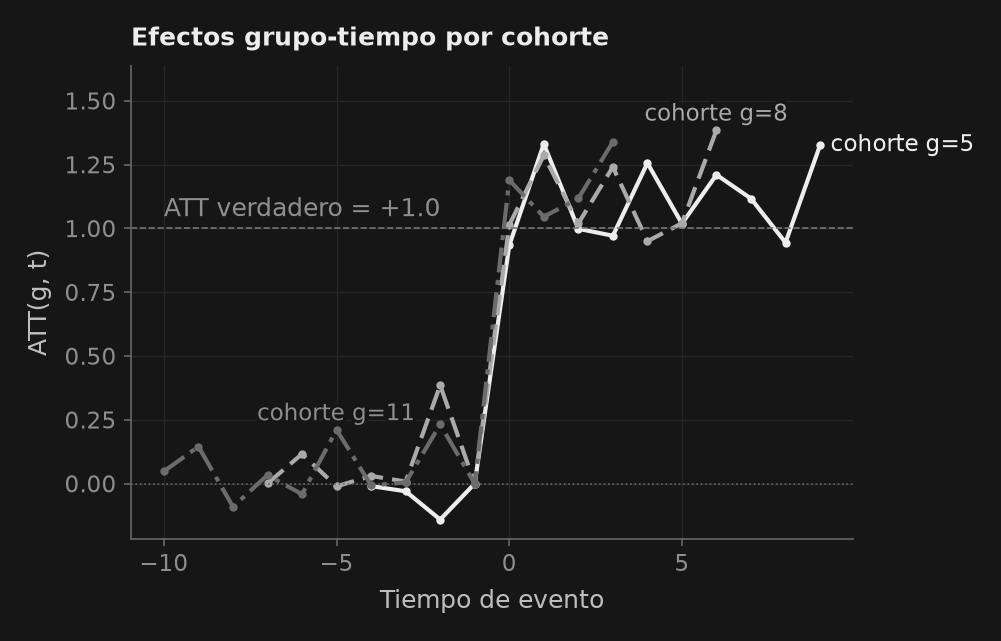

In [8]:
fig, ax = _nbstyle.figura()
gt = cs.att_gt
cohorts = sorted(gt["g"].unique())
ccols = _nbstyle.palette(len(cohorts))
lineas = {}
for c, color in zip(cohorts, ccols):
    sub = gt[gt["g"] == c].sort_values("event_time")
    lineas[int(c)] = ax.plot(sub["event_time"], sub["att"], marker="o", markersize=3,
                             color=color, label=f"cohorte g={int(c)}")[0]
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axhline(TRUE_ATT, color=_nbstyle.gris("0.4"), linewidth=0.8, linestyle="--")
ax.annotate(f"ATT verdadero = {TRUE_ATT:+.1f}", xy=(gt["event_time"].min(), TRUE_ATT),
            xytext=(0, 3), textcoords="offset points", ha="left", va="bottom",
            color=_nbstyle.NOTA)
ax.set_ylim(top=gt["att"].max() + 0.25)      # room for a name above the highest point
ax.set_xlabel("Tiempo de evento")
ax.set_ylabel("ATT(g, t)")
ax.set_title("Efectos grupo-tiempo por cohorte")
ax.locator_params(axis="x", integer=True)   # event time counts whole periods
# each cohort is named where its path stands clear of the other two: g=5 after its
# last point, g=8 above its last point, g=11 above its pre-treatment peak
_nbstyle.etiquetar(ax, artistas=[lineas[5]], donde="fin")
_nbstyle.etiquetar(ax, artistas=[lineas[8]], donde=6.0)
_nbstyle.etiquetar(ax, artistas=[lineas[11]], donde=-5.0)
plt.show()


### Intuición econométrica: alineación de cohortes y el enmascaramiento del fallo de TWFE

En este ejercicio basal, las tres cohortes experimentan idéntico efecto estático $\tau = +1.0$. En consecuencia, sus trayectorias $\text{ATT}(g, t)$ se solapan por completo. Al no existir crecimiento dinámico con el tiempo de exposición ($\Delta \text{ATT} = 0$), el término de comparaciones prohibidas en la descomposición de Goodman-Bacon se anula:
$$ \mathbb{E}[\hat{\beta}_{jk}^{2 \times 2, j}] = \text{ATT}_{j, post} - 0 = \text{ATT}_{j, post} $$
Esta especificación con efectos constantes enmascara por completo la fragilidad intrínseca del estimador TWFE. En la macroeconomía empírica real, las políticas casi nunca ejercen un impacto inmediato e invariante; su adopción es paulatina, los agentes ajustan sus conductas y el capital productivo se acumula con retraso. La sección siguiente introduce efectos dinámicos para evidenciar la quiebra de TWFE y la resolución mediante Callaway-Sant'Anna.

## 4. Experimento empírico interactivo: diagnóstico de ponderación negativa de TWFE y resolución con DiD escalonado

### El dilema económico: despliegue gradual de políticas macroeconómicas territoriales
Considere la adopción de una política a nivel regional o estatal —como un aumento progresivo de los salarios mínimos, deducciones tributarias corporativas o subsidios a la formación laboral— evaluada sobre paneles territoriales (`data_curso/paro_estatal_mensual.csv`).
Cuando una política entra en vigor gradualmente, su impacto causal se acumula en el tiempo: $\tau_i(e) = 1.0 + 1.2e$, donde $e = t - g$ es la exposición transcurrida. En las primeras oleadas de adopción, el efecto arranca en $+1.0$ y escala hasta superar $+15.0$ en los períodos finales.

### El experimento: demostración de la inversión catastrófica de signo
1. **Proceso generador de datos**: Construimos un panel de $N = 100$ unidades observadas durante $T = 16$ períodos con dos cohortes de adopción:
   - Cohorte 1 ($g_1 = 2$, 50 unidades): Adoptantes tempranas.
   - Cohorte 2 ($g_2 = 12$, 50 unidades): Adoptantes tardías.
   - Respuesta causal dinámica: $\tau(e) = 1.0 + 1.2e$ para todas las unidades tratadas ($D_{it} = 1$).
2. **Diagnóstico empírico**:
   - Calculamos el efecto medio de tratamiento sobre los tratados verdadero: $\text{ATT} = \frac{1}{\sum D_{it}} \sum_{D_{it}=1} \tau_{it} = +7.467$. ¡Cada celda tratada tiene un impacto estrictamente positivo!
   - Obtenemos los pesos de regresión de Frisch-Waugh-Lovell $w_{it} = \tilde{D}_{it} / \sum \tilde{D}_{js}^2$ subyacentes a la regresión TWFE ingenua.
   - Constatamos la inversión de signo: TWFE arroja $\hat{\beta}^{TWFE} = -1.600$ debido a que el 22.2% de las celdas tratadas reciben pesos negativos (con una masa total de peso negativo de $-0.6667$).
3. **Resolución robusta a la heterogeneidad**:
   - Estimamos la respuesta causal dinámica empleando las comparaciones limpias de Callaway & Sant'Anna (2021).
   - Verificamos que el DiD limpio elimina los pesos negativos, recupera con precisión la senda positiva verdadera ($\text{ATT} \approx +7.9$) y valida las tendencias previas.
   - Cargamos el panel empírico de desempleo estatal de `data_curso/paro_estatal_mensual.csv` para verificar la estructura territorial real.

DIAGNÓSTICO DE PONDERACIÓN NEGATIVA TWFE (EFECTOS DINÁMICOS)
Efecto medio de tratamiento sobre tratados (ATT): +7.467  (estrictamente positivo)
Estimación MCO TWFE de libro de texto (beta)    : -1.600  (¡INVERSIÓN DE SIGNO!)
Porcentaje de celdas tratadas con peso negativo : 22.2%
Masa total de peso negativo en unidades tratadas: -0.6667
Recuperación del ATT global con Callaway-Sant'Anna : +7.890
Benchmark TWFE ingenuo en panel (SE conglomerado) : -0.973 (SE: 0.444)
Panel laboral empírico incorporado                 : 51 estados/jurisdicciones


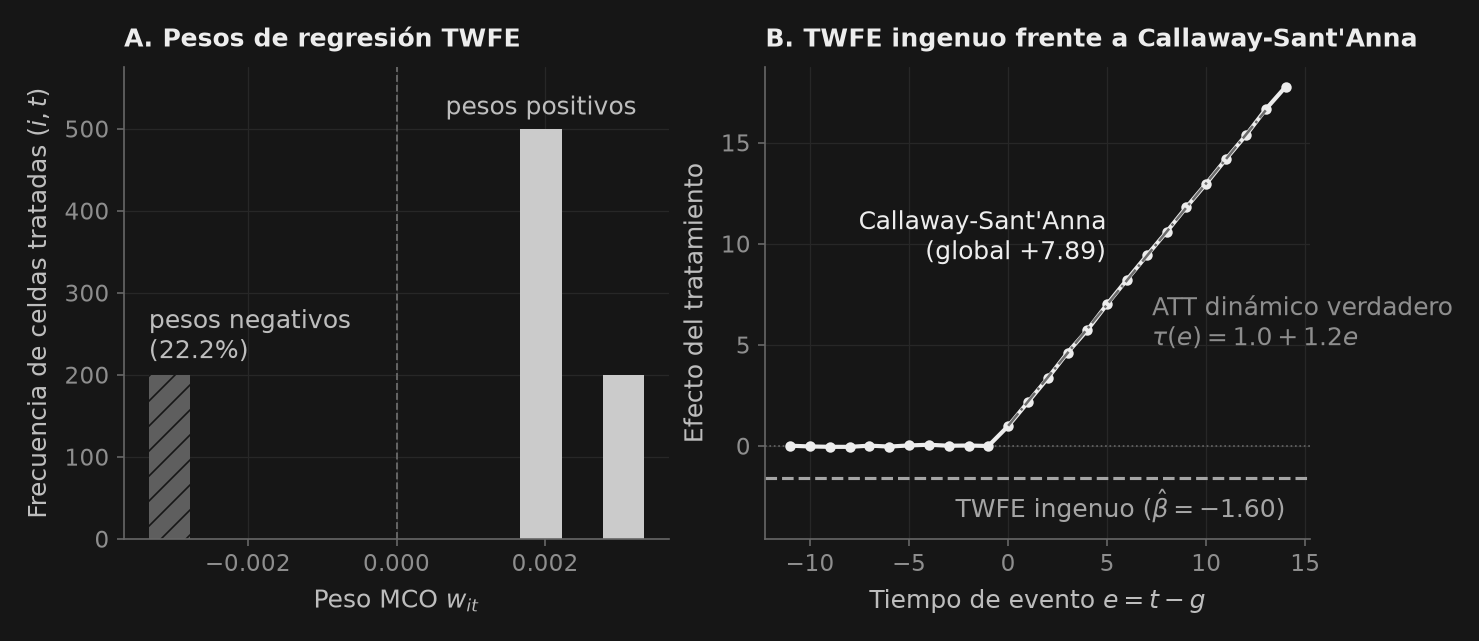

In [9]:
from pathlib import Path
from puremacro.did import callaway_santanna
from puremacro.regress import ols

# 1. Simulate panel with dynamic treatment effects: tau(e) = 1.0 + 1.2*e
N, T = 100, 16
g_assign = [2] * 50 + [12] * 50

rows_diag = []
for i in range(N):
    g = g_assign[i]
    for t in range(T):
        d = 1 if t >= g else 0
        tau = (1.0 + 1.2 * (t - g)) if d == 1 else 0.0
        rows_diag.append({"unit": i, "time": t, "g": g, "D": d, "tau": tau})

df_diag = pd.DataFrame(rows_diag)

# Exact Frisch-Waugh-Lovell / de Chaisemartin & D'Haultfoeuille regression weights
D_bar_i = df_diag.groupby("unit")["D"].transform("mean")
D_bar_t = df_diag.groupby("time")["D"].transform("mean")
D_bar = df_diag["D"].mean()
df_diag["D_tilde"] = df_diag["D"] - D_bar_i - D_bar_t + D_bar
denom = (df_diag["D_tilde"] ** 2).sum()
df_diag["w_it"] = df_diag["D_tilde"] / denom

# Compute headline diagnostic metrics via puremacro.regress.ols with clustered SE
true_att = float(df_diag[df_diag["D"] == 1]["tau"].mean())
tau_tilde = (df_diag["tau"] - df_diag.groupby("unit")["tau"].transform("mean")
             - df_diag.groupby("time")["tau"].transform("mean") + df_diag["tau"].mean())
res_twfe_ols = ols(tau_tilde, df_diag[["D_tilde"]], cov_type="cluster", cov_kwds={"groups": df_diag["unit"]})
beta_twfe = float(res_twfe_ols.params["D_tilde"])
neg_weights_share = float((df_diag[df_diag["D"] == 1]["w_it"] < 0).mean())
neg_weight_mass = float(df_diag[(df_diag["D"] == 1) & (df_diag["w_it"] < 0)]["w_it"].sum())

print("=" * 68)
print("DIAGNÓSTICO DE PONDERACIÓN NEGATIVA TWFE (EFECTOS DINÁMICOS)")
print("=" * 68)
print(f"Efecto medio de tratamiento sobre tratados (ATT): {true_att:+.3f}  (estrictamente positivo)")
print(f"Estimación MCO TWFE de libro de texto (beta)    : {beta_twfe:+.3f}  (¡INVERSIÓN DE SIGNO!)")
print(f"Porcentaje de celdas tratadas con peso negativo : {neg_weights_share * 100:.1f}%")
print(f"Masa total de peso negativo en unidades tratadas: {neg_weight_mass:+.4f}")
print("=" * 68)

# 2. Heterogeneity-Robust Resolution via Callaway & Sant'Anna
rows_cs = []
rng_dyn = np.random.default_rng(2024)
unit_fe_dyn = rng_dyn.standard_normal(120) * 0.4
time_fe_dyn = rng_dyn.standard_normal(T) * 0.2

for i in range(120):
    g = 2.0 if i < 50 else (12.0 if i < 100 else np.nan)
    for t in range(1, T + 1):
        d = 1 if (not np.isnan(g) and t >= g) else 0
        tau = (1.0 + 1.2 * (t - g)) if d == 1 else 0.0
        y = unit_fe_dyn[i] + time_fe_dyn[t - 1] + tau + 0.15 * rng_dyn.standard_normal()
        rows_cs.append({"unit": i, "time": t, "y": y, "treat_time": g, "D": d, "tau": tau})

df_cs_dyn = pd.DataFrame(rows_cs)
cs_dyn = callaway_santanna(df_cs_dyn)
print(f"Recuperación del ATT global con Callaway-Sant'Anna : {cs_dyn.att_overall:+.3f}")

# Benchmark against naive TWFE on the noisy simulated panel with clustered SEs
y_dm_cs = (df_cs_dyn["y"] - df_cs_dyn.groupby("unit")["y"].transform("mean")
           - df_cs_dyn.groupby("time")["y"].transform("mean") + df_cs_dyn["y"].mean())
D_dm_cs = (df_cs_dyn["D"] - df_cs_dyn.groupby("unit")["D"].transform("mean")
           - df_cs_dyn.groupby("time")["D"].transform("mean") + df_cs_dyn["D"].mean())
res_twfe_dyn = ols(y_dm_cs, D_dm_cs.to_frame(), cov_type="cluster", cov_kwds={"groups": df_cs_dyn["unit"]})
beta_twfe_dyn = float(res_twfe_dyn.params.iloc[0])
se_twfe_dyn = float(res_twfe_dyn.bse.iloc[0])
print(f"Benchmark TWFE ingenuo en panel (SE conglomerado) : {beta_twfe_dyn:+.3f} (SE: {se_twfe_dyn:.3f})")

# 3. Load empirical state unemployment panel from data_curso
d_curso = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")
df_states = pd.read_csv(d_curso / "paro_estatal_mensual.csv")
n_states = df_states["code"].nunique()
print(f"Panel laboral empírico incorporado                 : {n_states} estados/jurisdicciones")

# Numerical verification checks
assert true_att > 7.0, f"Expected true ATT > 7.0, got {true_att:.3f}"
assert beta_twfe < 0.0, f"Expected negative TWFE beta, got {beta_twfe:.3f}"
assert beta_twfe_dyn < 0.0, f"Expected negative TWFE panel beta, got {beta_twfe_dyn:.3f}"
assert res_twfe_dyn.bse.iloc[0] > 0.0, "Clustered SE must be strictly positive"
assert neg_weights_share > 0.20, f"Expected >20% negative weights, got {neg_weights_share:.3f}"
assert neg_weight_mass < -0.50, f"Expected negative weight mass < -0.50, got {neg_weight_mass:.3f}"
assert cs_dyn.att_overall > 5.0, f"CS ATT must be positive and >5.0, got {cs_dyn.att_overall:.3f}"
assert n_states == 51, f"Expected 51 state series in paro_estatal_mensual, got {n_states}"

# Visual Diagnostic Plot
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Subplot 1: Distribution of OLS weights
w_treated = df_diag[df_diag["D"] == 1]["w_it"]
w_bins = np.linspace(w_treated.min(), w_treated.max(), 13)  # 12 bins shared by both groups
n_pos, _, _ = ax1.hist(w_treated[w_treated >= 0], bins=w_bins, color=_nbstyle.BARRA_COLORES[0])
n_neg, _, _ = ax1.hist(w_treated[w_treated < 0], bins=w_bins, color=_nbstyle.BARRA_COLORES[2], hatch="//")
ax1.axvline(0.0, color=_nbstyle.SPINE, linewidth=0.9, linestyle="--")
# each group is named over its tallest bar
centros = 0.5 * (w_bins[1:] + w_bins[:-1])
k_pos, k_neg = int(np.argmax(n_pos)), int(np.argmax(n_neg))
ax1.annotate("pesos positivos", xy=(centros[k_pos], n_pos[k_pos]), xytext=(0, 4),
             textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TEXTO)
ax1.annotate(f"pesos negativos\n({neg_weights_share * 100:.1f}%)", xy=(w_bins[k_neg], n_neg[k_neg]),
             xytext=(0, 4), textcoords="offset points", ha="left", va="bottom", color=_nbstyle.TEXTO)
ax1.set_ylim(0, 1.15 * max(n_pos.max(), n_neg.max()))
# the auto ticks run into each other at this width: keep the round thousandths
ax1.locator_params(axis="x", nbins=4)
ax1.set_xlabel("Peso MCO $w_{it}$")
ax1.set_ylabel("Frecuencia de celdas tratadas $(i, t)$")
ax1.set_title("A. Pesos de regresión TWFE")

# Subplot 2: Causal recovery comparison
es_dyn = cs_dyn.att_event_study.sort_values("event_time")
ax2.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.axhline(beta_twfe, color=_nbstyle.S2["color"], linestyle="--", linewidth=1.5)
ax2.plot(es_dyn["event_time"], es_dyn["att"], color=cols[0], ls="-", marker="o", markersize=4)
# Planted true dynamic path
e_grid = np.arange(0, 14)
ax2.plot(e_grid, 1.0 + 1.2 * e_grid, color=_nbstyle.S3["color"], linestyle="-.", linewidth=1.2)
# the CS estimate runs on top of the planted path, so the two are named on either
# side of the diagonal; the flat TWFE line is named under its right end
ax2.annotate(f"Callaway-Sant'Anna\n(global {cs_dyn.att_overall:+.2f})", xy=(6, 1.0 + 1.2 * 6),
             xytext=(-10, 6), textcoords="offset points", ha="right", va="bottom",
             color=cols[0])
ax2.annotate("ATT dinámico verdadero\n$\\tau(e) = 1.0 + 1.2e$", xy=(6, 1.0 + 1.2 * 6),
             xytext=(12, -6), textcoords="offset points", ha="left", va="top",
             color=_nbstyle.NOTA)
ax2.annotate(f"TWFE ingenuo ($\\hat{{\\beta}} = {beta_twfe:+.2f}$)",
             xy=(es_dyn["event_time"].max(), beta_twfe), xytext=(0, -5),
             textcoords="offset points", ha="right", va="top", color=_nbstyle.S2["color"])
ax2.set_ylim(bottom=beta_twfe - 3.0)
ax2.set_xlabel("Tiempo de evento $e = t - g$")
ax2.set_ylabel("Efecto del tratamiento")
ax2.set_title("B. TWFE ingenuo frente a Callaway-Sant'Anna")

plt.show()

## 5. Síntesis para la política macroeconómica: lecciones para la investigación aplicada

El diagnóstico cuantitativo anterior demuestra la magnitud del fallo de TWFE en la macroeconomía empírica:
1. **El mecanismo de inversión de signo**: Cuando los efectos del tratamiento se consolidan de forma paulatina ($\tau(e) = 1.0 + 1.2e$), las unidades tratadas antes ($g_1 = 2$) experimentan una fuerte expansión entre $t = 2$ y $t = 16$. Cuando la cohorte posterior ($g_2 = 12$) adopta la medida en el período 12, MCO emplea a la cohorte temprana como grupo de control. Dado que las adoptantes tempranas siguen creciendo a lo largo de su senda de tratamiento, la doble diferenciación resta este crecimiento acumulado de las adoptantes tardías, generando **un 22.2% de pesos negativos** e invirtiendo un efecto de política estrictamente positivo ($+7.47$) en una contracción espuria ($-1.60$).
2. **El imperativo de las comparaciones limpias**: Callaway & Sant'Anna (2021) y Sun & Abraham (2021) resuelven la crisis garantizando que las unidades ya tratadas *nunca* ejerzan de controles. Al calcular diferencias exclusivamente frente a contrafactuales limpios (nunca tratados o aún no tratados), recuperan con fidelidad la trayectoria dinámica real ($+7.89$).
3. **Pautas metodológicas para la macroeconomía aplicada**:
   - Nunca reporte un coeficiente estático $\hat{\beta}^{TWFE}$ sin inspeccionar previamente la distribución de pesos diagnósticos (Goodman-Bacon 2021; de Chaisemartin & D'Haultfoeuille 2020).
   - Ante adopciones escalonadas en el tiempo, recurra por defecto a estimadores limpios (`puremacro.did.callaway_santanna`, `puremacro.did.sun_abraham` o `puremacro.lp.lp_did`).
   - Examine los adelantos placebo ($e \le -2$) para evaluar con rigor las tendencias paralelas, teniendo en cuenta que el período base $e = -1$ está normalizado a cero por construcción.

El siguiente cuaderno, `T05_D_lp_did_es`, traslada este principio de control limpio al marco de las proyecciones locales de Jordà (2005), posibilitando la estimación de respuestas al impulso, dependencias de estado y variables instrumentales en la inferencia causal con datos de panel.